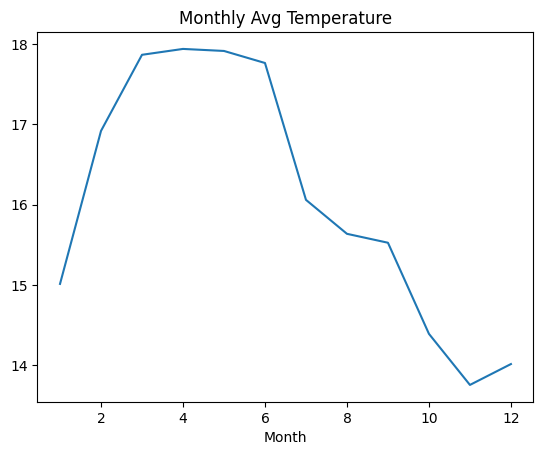

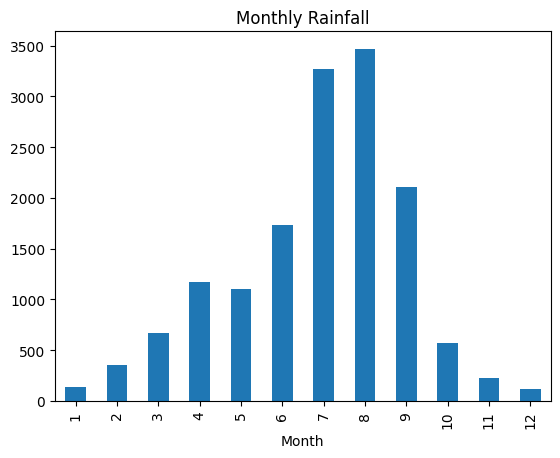

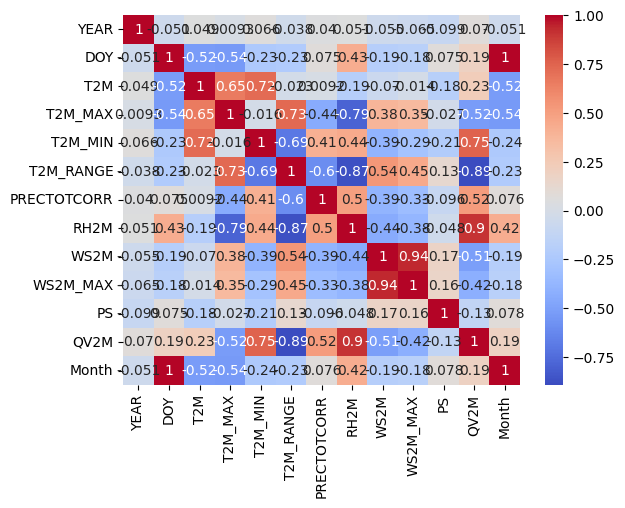

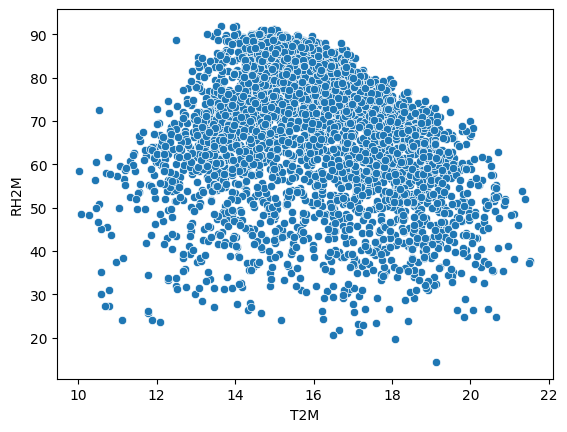

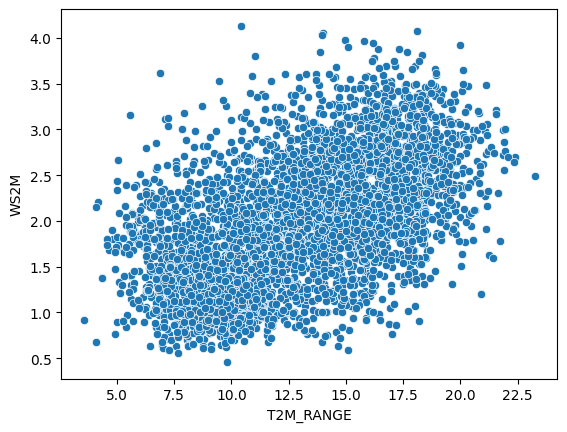

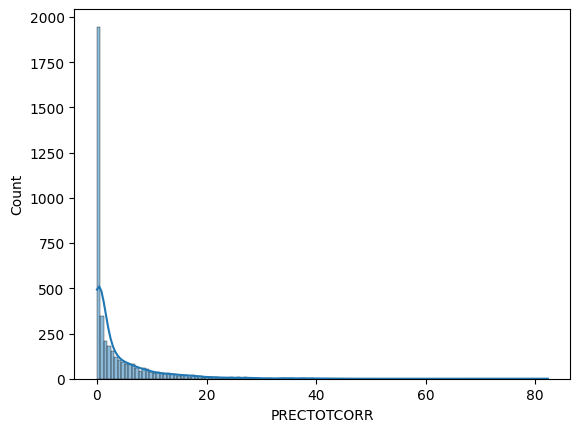

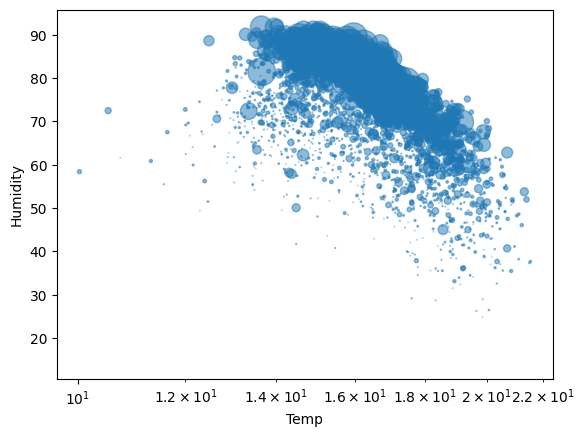

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

import os

os.makedirs("data", exist_ok=True)


df = pd.read_csv("ethiopia.csv")

# Add country column
df["Country"] = "Ethiopia"

# Convert to datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract month
df["Month"] = df["Date"].dt.month

df.replace(-999, np.nan, inplace=True)

df.duplicated().sum()
df = df.drop_duplicates()

df.describe()

missing = df.isna().sum()
percent = (missing / len(df)) * 100

pd.DataFrame({"Missing": missing, "Percent": percent})

# from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))

outliers = (z_scores > 3)
outlier_rows = np.where(outliers)[0]

len(outlier_rows)

df = df.ffill()

df.to_csv("data/ethiopia_clean.csv", index=False)

monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot()
plt.title("Monthly Avg Temperature")
plt.show()

monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

sns.histplot(df["PRECTOTCORR"], kde=True)
plt.show()

plt.xscale("log")

plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10, alpha=0.5)
plt.xlabel("Temp")
plt.ylabel("Humidity")
plt.show()

## Correlation Analysis of Climate Variables

The correlation heatmap reveals relationships between temperature, humidity, wind speed, and precipitation variables.

A noticeable inverse relationship exists between temperature and humidity, suggesting that higher temperatures are generally associated with lower humidity levels.

Wind speed shows weak to moderate correlations with other variables, indicating limited direct influence on temperature and precipitation.

Overall, the dataset shows expected meteorological relationships, confirming the internal consistency of the climate data.


## Temperature Range vs Wind Speed Analysis

The relationship between temperature range and wind speed appears weak, with no strong linear pattern visible in the scatter plot.

This suggests that wind speed does not significantly influence daily temperature variation in the dataset.

Any minor clustering observed may be due to local weather conditions or seasonal effects rather than a direct causal relationship.


## Rainfall Distribution Analysis

The rainfall distribution is highly skewed, with most values concentrated near zero and a few extreme values representing heavy rainfall events.

This indicates that rainfall in the region is intermittent, with long dry periods interrupted by occasional intense precipitation.

Such a distribution is typical for tropical or semi-arid climates where rainfall is seasonal and unevenly distributed.

## Multivariate Climate Relationship Analysis

The bubble chart combines temperature, humidity, and rainfall intensity to visualize their interaction.

Larger bubbles, representing higher rainfall, tend to cluster in specific temperature and humidity ranges, indicating that rainfall events are associated with particular climatic conditions.

This visualization highlights the interdependence of climate variables and helps identify conditions under which heavy rainfall is more likely to occur.

## Monthly Temperature Trend Analysis

The monthly average temperature shows a clear seasonal pattern over the observed period. Temperatures gradually increase during the early months of the year and peak around the hottest period, before declining again in the cooler months.

This pattern indicates a strong seasonal cycle in Ethiopia’s climate, likely influenced by regional atmospheric conditions and solar radiation changes throughout the year.

Overall, the temperature variation is consistent and does not show extreme anomalies, suggesting stable long-term climate behavior.